# Feature Engineering

This notebook prepares the cleaned insurance dataset for machine learning.

The following preprocessing steps are performed:

- Feature selection
- Train-test split
- Categorical feature encoding
- Numerical feature scaling
- Class imbalance handling
- Export of processed datasets

In [3]:
# Import all required libraries for feature engineering
# and data preprocessing.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler



In [4]:
# Load the cleaned dataset generated during
# exploratory data analysis.

df = pd.read_csv("../data/processed/insurance_clean.csv")

# Display dataset information including
# data types and missing values.

df.info()

# Verify that the cleaned dataset
# contains no missing values.

df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1680909 entries, 0 to 1680908
Data columns (total 21 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   individual_id        1680909 non-null  float64
 1   address_id           1680909 non-null  float64
 2   curr_ann_amt         1680909 non-null  float64
 3   days_tenure          1680909 non-null  float64
 4   cust_orig_date       1680909 non-null  str    
 5   age_in_years         1680909 non-null  int64  
 6   date_of_birth        1680909 non-null  str    
 7   latitude             1427190 non-null  float64
 8   longitude            1427190 non-null  float64
 9   city                 1668842 non-null  str    
 10  state                1680909 non-null  str    
 11  county               1668842 non-null  str    
 12  income               1680909 non-null  float64
 13  has_children         1680909 non-null  float64
 14  length_of_residence  1680909 non-null  float64
 15  marital_s

individual_id               0
address_id                  0
curr_ann_amt                0
days_tenure                 0
cust_orig_date              0
age_in_years                0
date_of_birth               0
latitude               253719
longitude              253719
city                    12067
state                       0
county                  12067
income                      0
has_children                0
length_of_residence         0
marital_status              0
home_market_value       92286
home_owner                  0
college_degree              0
good_credit                 0
Churn                       0
dtype: int64

In [5]:
# Select only the features required
# for the first machine learning model.

selected_features = [
    "age_in_years",
    "income",
    "curr_ann_amt",
    "days_tenure",
    "length_of_residence",
    "marital_status",
    "home_owner",
    "college_degree",
    "good_credit",
    "Churn"
]

df = df[selected_features]

df.isnull().sum()


age_in_years           0
income                 0
curr_ann_amt           0
days_tenure            0
length_of_residence    0
marital_status         0
home_owner             0
college_degree         0
good_credit            0
Churn                  0
dtype: int64

In [10]:
# Encode all categorical features

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_features = [
    "marital_status"
]

for column in categorical_features:
    df[column] = encoder.fit_transform(df[column])


df.head()

df.select_dtypes(include="object").columns

df.info()




<class 'pandas.DataFrame'>
RangeIndex: 1680909 entries, 0 to 1680908
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   age_in_years         1680909 non-null  int64  
 1   income               1680909 non-null  float64
 2   curr_ann_amt         1680909 non-null  float64
 3   days_tenure          1680909 non-null  float64
 4   length_of_residence  1680909 non-null  float64
 5   marital_status       1680909 non-null  int64  
 6   home_owner           1680909 non-null  float64
 7   college_degree       1680909 non-null  float64
 8   good_credit          1680909 non-null  float64
 9   Churn                1680909 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 128.2 MB


In [28]:
# Features and target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Standardize the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



# Logistic Regression is the first model and prediction

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# Evaluation the model

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.6054250376284275
Precision : 0.17406024949005786
Recall : 0.6484195290894523
F1 Score : 0.2744482428551894


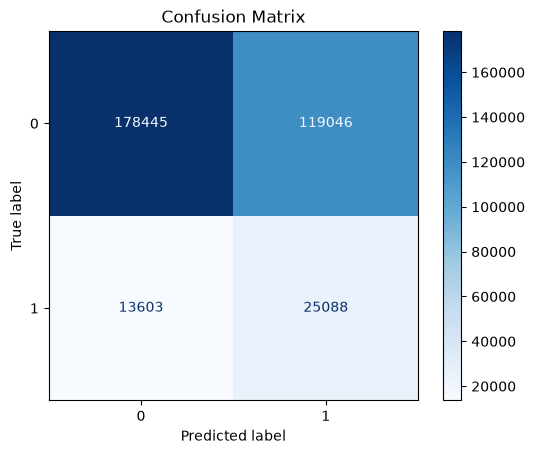

In [29]:
# Create a Confusion Matrix 

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()



In [30]:
# Compute the ROC-AUC

from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)


ROC-AUC: 0.6871093549458527


In [32]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Abs"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Abs",
    ascending=False
)

feature_importance


,Feature,Coefficient,Abs
3,days_tenure,-0.604263,0.604263
2,curr_ann_amt,0.068662,0.068662
4,length_of_residence,-0.062763,0.062763
7,college_degree,-0.030617,0.030617
0,age_in_years,0.026217,0.026217
5,marital_status,-0.021555,0.021555
8,good_credit,-0.013574,0.013574
1,income,-0.004977,0.004977
6,home_owner,0.004820,0.004820


In [34]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance



Accuracy : 0.8264957671737333
Precision: 0.24307917735098644
Recall   : 0.24010751854436432
F1 Score : 0.2415842099104136


,Feature,Importance
2,curr_ann_amt,0.334183
3,days_tenure,0.322785
1,income,0.099862
0,age_in_years,0.096254
4,length_of_residence,0.091128
7,college_degree,0.016029
5,marital_status,0.014343
6,home_owner,0.012939
8,good_credit,0.012476


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance


Accuracy : 0.8674081301199945
Precision: 0.41903792173482307
Recall   : 0.3935540564989274
F1 Score : 0.40589638673046424


,Feature,Importance
3,days_tenure,0.350512
2,curr_ann_amt,0.326824
0,age_in_years,0.125338
1,income,0.089381
4,length_of_residence,0.071683
5,marital_status,0.011678
8,good_credit,0.008642
6,home_owner,0.007992
7,college_degree,0.007949


KeyboardInterrupt: 

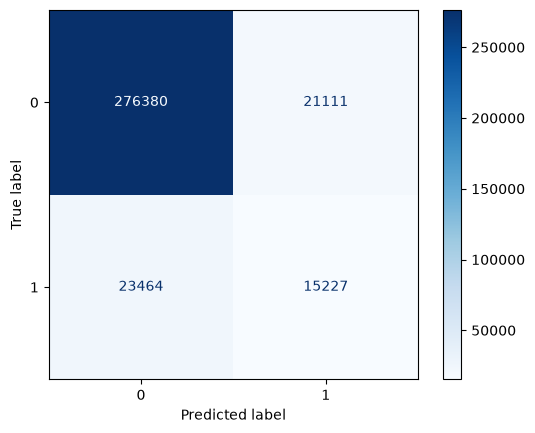

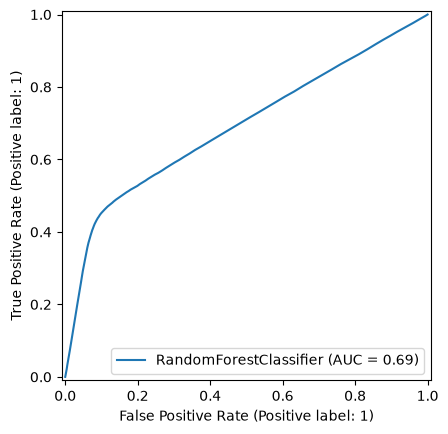

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

print(scores)
print(scores.mean())
